# Phase 2 — Data Engineering & Feature Engineering

This notebook transforms the raw vehicle-level `InOut` dataset into a regular, leakage-safe time-series dataset suitable for machine-learning forecasting.

The forecasting target is **active vehicle count / in-system occupancy**, which is used as a congestion proxy because the raw dataset does not contain a direct physical queue-length measurement.

The transformation process is designed to be deterministic and reusable. Exploratory analysis and model training are maintained separately from this data-engineering workflow.

The main stages are:

1. Load and validate raw data
2. Construct a regular 15-minute event series
3. Reconstruct active-vehicle occupancy
4. Handle unreliable observation periods
5. Create historical and flow-based features
6. Create future occupancy targets
7. Check temporal leakage and feature availability
8. Produce the final ML-ready dataset

In [16]:
import pandas as pd

file_path = "Vehicle_Data_ DwellTime _Tra.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="InOut"
)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (77432, 8)

Columns:
['Country', 'Plate Prefix', 'Plate Number', 'Entry Time', 'Exit Time', 'Risk Category', 'Duration in Min', 'Time Taken']


,Country,Plate Prefix,Plate Number,Entry Time,Exit Time,Risk Category,Duration in Min,Time Taken
0,NaN,NaN,NaN,2026-08-01 00:00:01.807,2026-08-01 01:33:09.439,GREEN,93.13,1 hr 33 min
1,NaN,NaN,NaN,2026-08-01 00:00:38.107,2026-08-01 01:45:43.918,GREEN,105.10,1 hr 45 min
2,NaN,NaN,NaN,2026-08-01 00:00:56.237,2026-08-01 02:15:55.371,GREEN,134.98,2 hr 14 min
3,NaN,NaN,NaN,2026-08-01 00:02:00.193,2026-08-01 01:56:26.812,GREEN,114.45,1 hr 54 min
4,NaN,NaN,NaN,2026-08-01 00:02:50.141,2026-08-01 01:56:07.121,GREEN,113.28,1 hr 53 min


## 1. Raw Data Selection and Standardization

The forecasting pipeline uses the fields that contain information relevant to vehicle flow, dwell behavior, and contextual classification.

The following fields are retained:

- `Entry Time`
- `Exit Time`
- `Risk Category`
- `Duration in Min`

The vehicle-identification fields `Country`, `Plate Prefix`, and `Plate Number` are excluded because they contain no usable values in the supplied dataset.

`Time Taken` is excluded because it is a redundant human-readable representation of the dwell duration.

Missing `Risk Category` values are represented as `UNKNOWN`. The corresponding records are retained because their entry, exit, and dwell information remains valid.

In [17]:
df = df[
    [
        "Entry Time",
        "Exit Time",
        "Risk Category",
        "Duration in Min"
    ]
].copy()

df["Risk Category"] = (
    df["Risk Category"]
    .fillna("UNKNOWN")
)

print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nRisk Category:")
print(df["Risk Category"].value_counts())

Shape: (77432, 4)

Missing values:
Entry Time         0
Exit Time          0
Risk Category      0
Duration in Min    0
dtype: int64

Risk Category:
Risk Category
GREEN      50075
UNKNOWN    26427
RED          930
Name: count, dtype: int64


## 2. Construct the Canonical 15-Minute Time Grid

The vehicle-level entry and exit events are aggregated into a regular 15-minute time series.

Every 15-minute interval must be represented, including intervals in which no vehicle enters or exits.

For a valid observed interval with no events:

- `arrivals = 0`
- `exits = 0`
- `net_flow = 0`

The resulting time index must therefore contain consecutive timestamps separated by exactly 15 minutes.

This regular structure is essential because lag features must represent fixed amounts of historical time. For example:

- lag 1 = 15 minutes earlier
- lag 4 = 1 hour earlier
- lag 24 = 6 hours earlier
- lag 96 = 24 hours earlier
- lag 672 = 7 days earlier

An event-free interval and an unreliable observation period are treated differently. A valid event-free interval receives zero event counts, while an unreliable interval is retained in the time grid but is later excluded from supervised learning.

In [18]:
# Create 15-minute buckets
df["Entry Bucket"] = df["Entry Time"].dt.floor("15min")
df["Exit Bucket"] = df["Exit Time"].dt.floor("15min")

# Aggregate arrivals
arrivals = (
    df.groupby("Entry Bucket")
      .size()
      .rename("arrivals")
)

# Aggregate exits
exits = (
    df.groupby("Exit Bucket")
      .size()
      .rename("exits")
)

# Combine event counts
events_15min = pd.concat(
    [arrivals, exits],
    axis=1,
    sort=False
).fillna(0)

# Create a COMPLETE 15-minute time grid
start_time = df["Entry Time"].min().floor("15min")
end_time = df["Exit Time"].max().floor("15min")

full_index = pd.date_range(
    start=start_time,
    end=end_time,
    freq="15min"
)

events_15min = (
    events_15min
    .reindex(full_index, fill_value=0)
)

events_15min.index.name = "timestamp"

# Net flow
events_15min["net_flow"] = (
    events_15min["arrivals"]
    - events_15min["exits"]
)

# Reconstruct occupancy
events_15min["active_vehicles"] = (
    events_15min["net_flow"].cumsum()
)

occupancy_15min = events_15min.copy()

print("Total intervals:", len(occupancy_15min))
print("Start:", occupancy_15min.index.min())
print("End:", occupancy_15min.index.max())

Total intervals: 4650
Start: 2026-08-01 00:00:00
End: 2026-09-18 10:15:00


In [19]:
time_gaps = (
    occupancy_15min.index.to_series()
    .diff()
    .dropna()
)

print("Unique time gaps:")
print(time_gaps.value_counts())

print("\nAug 22 intervals:",
      occupancy_15min.loc["2026-08-22"].shape[0])

print("Aug 23 intervals:",
      occupancy_15min.loc["2026-08-23"].shape[0])

print(
    "Aug 24 00:00-11:45 intervals:",
    occupancy_15min.loc[
        "2026-08-24 00:00":"2026-08-24 11:45"
    ].shape[0]
)

print("\nTotal arrivals:",
      occupancy_15min["arrivals"].sum())

print("Total exits:",
      occupancy_15min["exits"].sum())

print("Minimum occupancy:",
      occupancy_15min["active_vehicles"].min())

print("Final occupancy:",
      occupancy_15min["active_vehicles"].iloc[-1])

Unique time gaps:
timestamp
0 days 00:15:00    4649
Name: count, dtype: int64

Aug 22 intervals: 96
Aug 23 intervals: 96
Aug 24 00:00-11:45 intervals: 48

Total arrivals: 77432.0
Total exits: 77432.0
Minimum occupancy: 0.0
Final occupancy: 0.0


## 3. Reconstruct Active Vehicle Occupancy

The dataset does not contain a direct physical queue-length measurement.

Active vehicle count is therefore reconstructed from the entry and exit flow.

For each 15-minute interval:

\[
A_t =
A_{t-1}
+
Arrivals_t - Exits_t
\]

where \(A_t\) represents the number of vehicles remaining inside the observed system at the interval boundary.

This quantity is referred to as **active vehicle count** or **in-system occupancy** and is used as a congestion/queue proxy.

It should not be interpreted as a direct physical queue-length measurement.

In [20]:
events_15min["active_vehicles"] = (
    events_15min["net_flow"].cumsum()
)

occupancy_15min = events_15min.copy()

display(occupancy_15min.head(10))

,arrivals,exits,net_flow,active_vehicles
timestamp,,,,
2026-08-01 00:00:00,17.0,0.0,17.0,17.0
2026-08-01 00:15:00,7.0,0.0,7.0,24.0
2026-08-01 00:30:00,10.0,0.0,10.0,34.0
2026-08-01 00:45:00,17.0,0.0,17.0,51.0
2026-08-01 01:00:00,27.0,0.0,27.0,78.0
2026-08-01 01:15:00,10.0,0.0,10.0,88.0
2026-08-01 01:30:00,13.0,1.0,12.0,100.0
2026-08-01 01:45:00,11.0,12.0,-1.0,99.0
2026-08-01 02:00:00,17.0,4.0,13.0,112.0


In [21]:
print("Total arrivals:",
      occupancy_15min["arrivals"].sum())

print("Total exits:",
      occupancy_15min["exits"].sum())

print("Minimum active vehicles:",
      occupancy_15min["active_vehicles"].min())

print("Maximum active vehicles:",
      occupancy_15min["active_vehicles"].max())

print("Final active vehicles:",
      occupancy_15min["active_vehicles"].iloc[-1])


Total arrivals: 77432.0
Total exits: 77432.0
Minimum active vehicles: 0.0
Maximum active vehicles: 493.0
Final active vehicles: 0.0


## 4. Observation Reliability and Gap Handling

The canonical time series retains every 15-minute interval, including intervals with no recorded vehicle events.

However, the August 22–23 period contains incomplete vehicle-entry coverage. The absence of recorded entries during this period cannot be interpreted as zero traffic because the underlying observations may be missing.

A reliability indicator is therefore used to distinguish reliable observed intervals from intervals affected by incomplete data coverage.

The following periods are treated as unreliable:

- August 22, 2026
- August 23, 2026
- August 24, 2026 from 00:00 through 11:45

The post-gap washout period is based on the approximately 720-minute maximum observed dwell duration. This is a conservative engineering assumption rather than a confirmed operational limit.

The underlying arrival, exit, net-flow, and occupancy values are not modified. The reliability indicator is used later to determine whether a timestamp can safely participate in feature construction and supervised learning.

In [26]:
incomplete_dates = pd.to_datetime([
    "2026-08-22",
    "2026-08-23"
]).date

ml_base = occupancy_15min.copy()

# All intervals are initially considered reliable
ml_base["is_reliable"] = True

# Mark the incomplete dates
date_mask = pd.Series(
    ml_base.index.date,
    index=ml_base.index
).isin(incomplete_dates)

ml_base.loc[date_mask, "is_reliable"] = False

# Conservative 12-hour post-gap washout
washout_start = pd.Timestamp("2026-08-24 00:00")
washout_end = pd.Timestamp("2026-08-24 12:00")

ml_base.loc[
    (ml_base.index >= washout_start) &
    (ml_base.index < washout_end),
    "is_reliable"
] = False

print("Total intervals:", len(ml_base))
print("Reliable intervals:", ml_base["is_reliable"].sum())
print("Unreliable intervals:", (~ml_base["is_reliable"]).sum())

Total intervals: 4650
Reliable intervals: 4410
Unreliable intervals: 240


In [27]:
print("\nReliability around the gap:")

display(
    ml_base.loc[
        "2026-08-21":"2026-08-24 12:15",
        [
            "arrivals",
            "exits",
            "net_flow",
            "active_vehicles",
            "is_reliable"
        ]
    ]
)


Reliability around the gap:


,arrivals,exits,net_flow,active_vehicles,is_reliable
timestamp,,,,,
2026-08-21 00:00:00,15.0,10.0,5.0,229.0,True
2026-08-21 00:15:00,8.0,10.0,-2.0,227.0,True
2026-08-21 00:30:00,11.0,14.0,-3.0,224.0,True
2026-08-21 00:45:00,14.0,21.0,-7.0,217.0,True
2026-08-21 01:00:00,21.0,13.0,8.0,225.0,True
...,...,...,...,...,...
2026-08-24 11:15:00,28.0,19.0,9.0,118.0,False
2026-08-24 11:30:00,25.0,20.0,5.0,123.0,False
2026-08-24 11:45:00,27.0,19.0,8.0,131.0,False


## 5. Statistical Lag Selection

Lag features will be selected using evidence from the occupancy time series rather than being added arbitrarily.

The first stage uses the autocorrelation function (ACF) to examine how strongly current occupancy is related to occupancy at different historical time lags.

Because the canonical time series has a 15-minute frequency:

- lag 1 = 15 minutes
- lag 4 = 1 hour
- lag 8 = 2 hours
- lag 12 = 3 hours
- lag 24 = 6 hours
- lag 96 = 24 hours
- lag 672 = 7 days

The August 22–23 observation gap and the associated post-gap washout are treated as unreliable and are excluded from the statistical calculation rather than being interpreted as zero occupancy.

The purpose of ACF/PACF analysis is to identify **candidate** lag features. It does not by itself determine the final feature set. Candidate lags will later be evaluated using model-based feature importance and chronological validation.

In [29]:
from statsmodels.tsa.stattools import acf

occupancy_for_lag_analysis = (
    ml_base["active_vehicles"]
    .where(ml_base["is_reliable"])
)

acf_values = acf(
    occupancy_for_lag_analysis.dropna(),
    nlags=672,
    fft=True
)

acf_df = pd.DataFrame({
    "lag_steps": range(len(acf_values)),
    "lag_minutes": range(len(acf_values)),
    "autocorrelation": acf_values
})

acf_df["lag_minutes"] = (
    acf_df["lag_steps"] * 15
)

display(acf_df.head(20))

,lag_steps,lag_minutes,autocorrelation
0,0,0,1.000000
1,1,15,0.988612
2,2,30,0.970089
3,3,45,0.948620
4,4,60,0.925342
5,5,75,0.901219
6,6,90,0.876316
7,7,105,0.851074
8,8,120,0.825680
9,9,135,0.800547


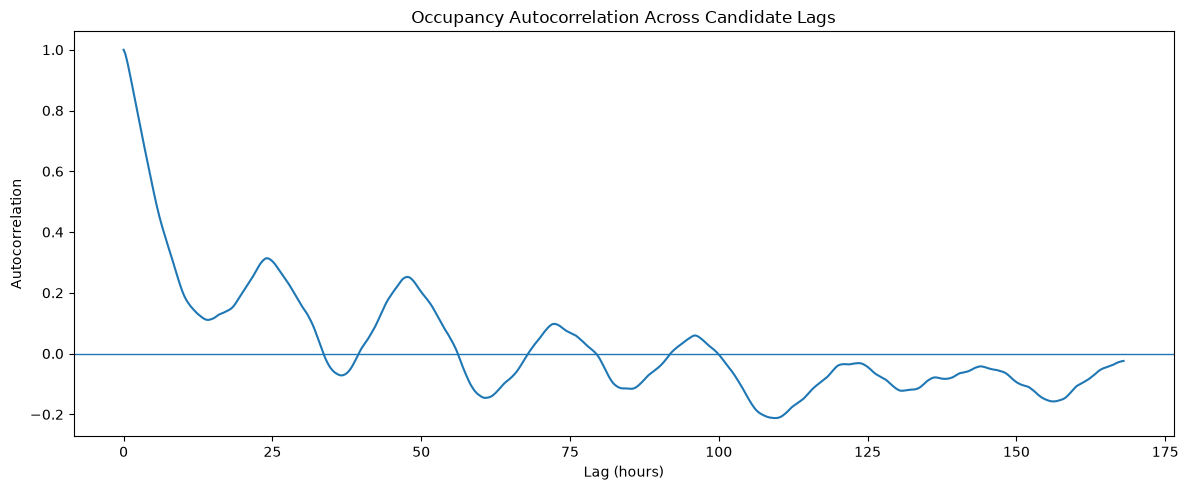

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    acf_df["lag_minutes"] / 60,
    acf_df["autocorrelation"]
)

plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.title("Occupancy Autocorrelation Across Candidate Lags")

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [31]:
occupancy_for_lag_analysis = (
    ml_base["active_vehicles"]
    .where(ml_base["is_reliable"])
)

max_lag = 672

acf_values = []

for lag in range(1, max_lag + 1):
    acf_values.append(
        occupancy_for_lag_analysis.autocorr(lag=lag)
    )

acf_df = pd.DataFrame({
    "lag_steps": range(1, max_lag + 1),
    "lag_minutes": [lag * 15 for lag in range(1, max_lag + 1)],
    "autocorrelation": acf_values
})

display(acf_df.head(20))

,lag_steps,lag_minutes,autocorrelation
0,1,15,0.989512
1,2,30,0.971816
2,3,45,0.951102
3,4,60,0.928470
4,5,75,0.904885
5,6,90,0.880487
6,7,105,0.855685
7,8,120,0.830677
8,9,135,0.805892
9,10,150,0.781491


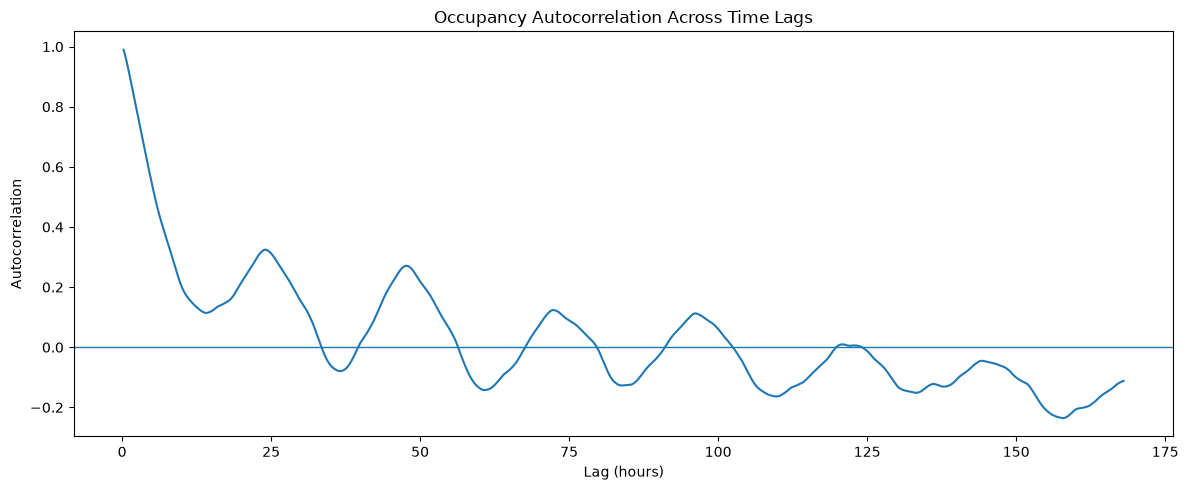

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    acf_df["lag_minutes"] / 60,
    acf_df["autocorrelation"]
)

plt.xlabel("Lag (hours)")
plt.ylabel("Autocorrelation")
plt.title("Occupancy Autocorrelation Across Time Lags")

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [33]:
reliable_mask = ml_base["is_reliable"]

segment_id = (
    reliable_mask.ne(reliable_mask.shift())
    .cumsum()
)

reliable_segments = (
    ml_base[reliable_mask]
    .groupby(segment_id[reliable_mask])
    .agg(
        start=("active_vehicles", lambda x: x.index.min()),
        end=("active_vehicles", lambda x: x.index.max()),
        observations=("active_vehicles", "size")
    )
    .sort_values("observations", ascending=False)
)

display(reliable_segments)

,start,end,observations
is_reliable,,,
3,2026-08-24 12:00:00,2026-09-18 10:15:00,2394
1,2026-08-01 00:00:00,2026-08-21 23:45:00,2016


### 5.2 Partial Autocorrelation of Occupancy

Partial autocorrelation (PACF) is used to identify historical lags that may contain additional information about current occupancy after accounting for shorter historical lags.

The PACF analysis is performed on the longest continuous reliable occupancy segment so that the August 22–23 observation gap does not artificially compress the time axis.

PACF is used as a candidate-lag selection tool rather than as a rule for automatically selecting model features. Candidate lags will later be evaluated using tree-model feature importance and chronological out-of-sample validation.

In [34]:
longest_segment_id = reliable_segments["observations"].idxmax()

pacf_series = (
    ml_base.loc[
        ml_base["is_reliable"] &
        (segment_id == longest_segment_id),
        "active_vehicles"
    ]
)

print("PACF observations:", len(pacf_series))
print("Start:", pacf_series.index.min())
print("End:", pacf_series.index.max())

PACF observations: 2394
Start: 2026-08-24 12:00:00
End: 2026-09-18 10:15:00


In [35]:
from statsmodels.tsa.stattools import pacf

pacf_values = pacf(
    pacf_series,
    nlags=672,
    method="ywm"
)

pacf_df = pd.DataFrame({
    "lag_steps": range(len(pacf_values)),
    "lag_minutes": [lag * 15 for lag in range(len(pacf_values))],
    "partial_autocorrelation": pacf_values
})

display(pacf_df.head(20))

,lag_steps,lag_minutes,partial_autocorrelation
0,0,0,1.000000
1,1,15,0.984627
2,2,30,-0.331382
3,3,45,-0.060096
4,4,60,-0.037232
5,5,75,-0.031259
6,6,90,-0.022461
7,7,105,-0.023548
8,8,120,-0.020749
9,9,135,-0.003918


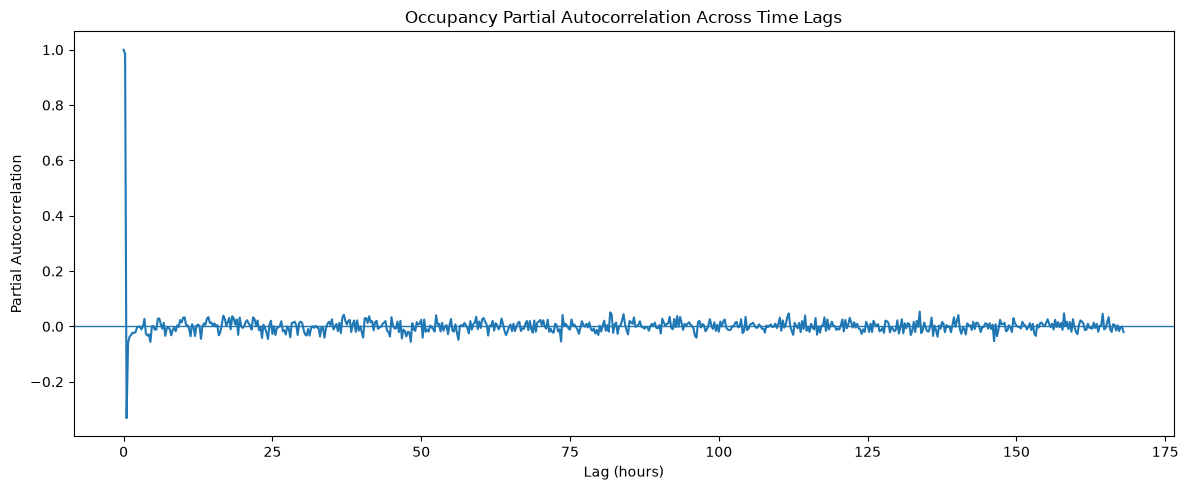

In [36]:
plt.figure(figsize=(12, 5))

plt.plot(
    pacf_df["lag_minutes"] / 60,
    pacf_df["partial_autocorrelation"]
)

plt.xlabel("Lag (hours)")
plt.ylabel("Partial Autocorrelation")
plt.title("Occupancy Partial Autocorrelation Across Time Lags")

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

### 5.3 PACF Significance Check

The PACF values are examined together with an approximate 95% confidence interval to distinguish potentially meaningful partial autocorrelation from fluctuations that may occur by chance.

The confidence interval is used as a statistical diagnostic rather than as an automatic feature-selection rule. Even statistically noticeable lags may be redundant with other features or fail to improve out-of-sample forecasting performance.

The primary goal is to identify a compact set of candidate lags for subsequent model-based evaluation.

In [37]:
from statsmodels.tsa.stattools import pacf

pacf_values, confint = pacf(
    pacf_series,
    nlags=672,
    alpha=0.05,
    method="ywm"
)

pacf_df = pd.DataFrame({
    "lag_steps": range(len(pacf_values)),
    "lag_minutes": [lag * 15 for lag in range(len(pacf_values))],
    "partial_autocorrelation": pacf_values,
    "lower_ci": confint[:, 0],
    "upper_ci": confint[:, 1]
})

display(pacf_df.head(20))

,lag_steps,lag_minutes,partial_autocorrelation,lower_ci,upper_ci
0,0,0,1.000000,1.000000,1.000000
1,1,15,0.984627,0.944570,1.024685
2,2,30,-0.331382,-0.371440,-0.291324
3,3,45,-0.060096,-0.100154,-0.020039
4,4,60,-0.037232,-0.077290,0.002825
5,5,75,-0.031259,-0.071316,0.008799
6,6,90,-0.022461,-0.062519,0.017596
7,7,105,-0.023548,-0.063606,0.016510
8,8,120,-0.020749,-0.060807,0.019309
9,9,135,-0.003918,-0.043975,0.036140


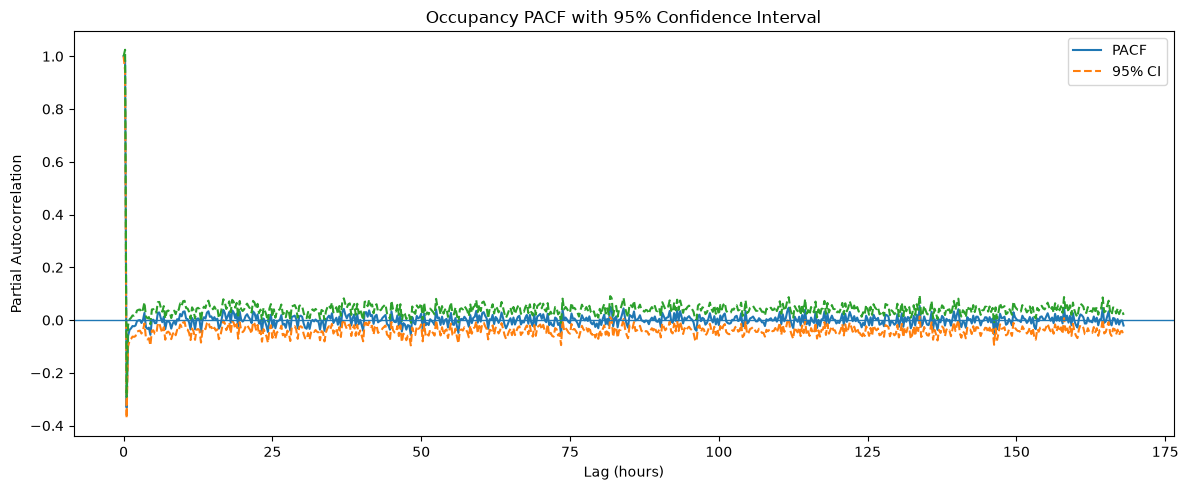

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    pacf_df["lag_minutes"] / 60,
    pacf_df["partial_autocorrelation"],
    label="PACF"
)

plt.plot(
    pacf_df["lag_minutes"] / 60,
    pacf_df["lower_ci"],
    linestyle="--",
    label="95% CI"
)

plt.plot(
    pacf_df["lag_minutes"] / 60,
    pacf_df["upper_ci"],
    linestyle="--"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Lag (hours)")
plt.ylabel("Partial Autocorrelation")
plt.title("Occupancy PACF with 95% Confidence Interval")
plt.legend()

plt.tight_layout()
plt.show()

## 5. Occupancy Lag Features

Historical occupancy features are created to provide the model with information about the recent and longer-term state of the system.

Because the occupancy time series has a 15-minute frequency, each lag corresponds to a specific amount of past time:

- 1 lag = 15 minutes
- 2 lags = 30 minutes
- 4 lags = 1 hour
- 8 lags = 2 hours
- 12 lags = 3 hours
- 16 lags = 4 hours
- 24 lags = 6 hours
- 96 lags = 24 hours

The initial candidate set is intentionally focused rather than generating a large number of lag features. Feature importance and chronological validation will later determine which features are actually useful.

In [42]:
ml_base = occupancy_15min.copy()

candidate_lags = {
    "lag_15m": 1,
    "lag_30m": 2,
    "lag_1h": 4,
    "lag_2h": 8,
    "lag_3h": 12,
    "lag_4h": 16,
    "lag_6h": 24,
    "lag_24h": 96
}

for feature_name, lag_steps in candidate_lags.items():
    ml_base[feature_name] = ml_base["active_vehicles"].shift(lag_steps)

In [43]:
print("Shape:", ml_base.shape)

display(
    ml_base[
        [
            "active_vehicles",
            "lag_15m",
            "lag_30m",
            "lag_1h",
            "lag_2h",
            "lag_3h",
            "lag_4h",
            "lag_6h",
            "lag_24h"
        ]
    ].head(20)
)

Shape: (4650, 12)


,active_vehicles,lag_15m,lag_30m,lag_1h,lag_2h,lag_3h,lag_4h,lag_6h,lag_24h
timestamp,,,,,,,,,
2026-08-01 00:00:00,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-01 00:15:00,24.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-01 00:30:00,34.0,24.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-01 00:45:00,51.0,34.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-01 01:00:00,78.0,51.0,34.0,17.0,NaN,NaN,NaN,NaN,NaN
2026-08-01 01:15:00,88.0,78.0,51.0,24.0,NaN,NaN,NaN,NaN,NaN
2026-08-01 01:30:00,100.0,88.0,78.0,34.0,NaN,NaN,NaN,NaN,NaN
2026-08-01 01:45:00,99.0,100.0,88.0,51.0,NaN,NaN,NaN,NaN,NaN
2026-08-01 02:00:00,112.0,99.0,100.0,78.0,17.0,NaN,NaN,NaN,NaN


## 6. Observation Reliability and Gap Handling

The canonical 15-minute time series contains every 15-minute interval, including intervals with no recorded events.

However, August 22 and August 23 contain incomplete entry observations. These intervals therefore cannot be treated as genuine zero-traffic observations.

A reliability flag is added to identify intervals that can be safely used for machine-learning feature construction.

The following periods are marked as unreliable:

- August 22, 2026
- August 23, 2026
- August 24, 2026 from 00:00 to 11:45

A 12-hour post-gap washout period is used as a conservative engineering assumption based on the observed maximum dwell duration of approximately 720 minutes.

The underlying occupancy and flow values are not modified. Only the reliability status is recorded.

In [44]:
ml_base["is_reliable"] = True

incomplete_dates = pd.to_datetime([
    "2026-08-22",
    "2026-08-23"
]).date

date_mask = pd.Series(
    ml_base.index.date,
    index=ml_base.index
).isin(incomplete_dates)

ml_base.loc[date_mask, "is_reliable"] = False

washout_start = pd.Timestamp("2026-08-24 00:00")
washout_end = pd.Timestamp("2026-08-24 12:00")

washout_mask = (
    (ml_base.index >= washout_start) &
    (ml_base.index < washout_end)
)

ml_base.loc[washout_mask, "is_reliable"] = False

In [45]:
print("Total intervals:", len(ml_base))
print("Reliable intervals:", ml_base["is_reliable"].sum())
print("Unreliable intervals:", (~ml_base["is_reliable"]).sum())

Total intervals: 4650
Reliable intervals: 4410
Unreliable intervals: 240


### 6.3 Reliability-Aware Occupancy Lags

An occupancy lag is considered valid only when the historical timestamp from which the lag is taken is reliable.

This prevents the model from using historical occupancy values that were reconstructed from incomplete observation periods.

Lag values whose source observation is unreliable are therefore set to missing. These missing values are handled later when constructing the supervised training dataset.

In [46]:
for feature_name, lag_steps in candidate_lags.items():
    source_reliable = (
        ml_base["is_reliable"]
        .shift(lag_steps, fill_value=False)
        .astype("boolean")
    )

    ml_base[feature_name] = ml_base[feature_name].mask(
        ~source_reliable
    )

In [48]:
display(
    ml_base.loc[
        "2026-08-24 00:00":"2026-08-25 18:00",
        [
            "active_vehicles",
            "is_reliable",
            "lag_15m",
            "lag_1h",
            "lag_6h",
            "lag_24h"
        ]
    ]
)

,active_vehicles,is_reliable,lag_15m,lag_1h,lag_6h,lag_24h
timestamp,,,,,,
2026-08-24 00:00:00,1.0,False,NaN,NaN,NaN,NaN
2026-08-24 00:15:00,1.0,False,NaN,NaN,NaN,NaN
2026-08-24 00:30:00,2.0,False,NaN,NaN,NaN,NaN
2026-08-24 00:45:00,3.0,False,NaN,NaN,NaN,NaN
2026-08-24 01:00:00,4.0,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2026-08-25 17:00:00,180.0,True,188.0,202.0,163.0,157.0
2026-08-25 17:15:00,180.0,True,180.0,194.0,156.0,150.0
2026-08-25 17:30:00,198.0,True,180.0,186.0,160.0,156.0


In [49]:
display(
    ml_base.loc[
        [
            "2026-08-24 11:45",
            "2026-08-24 12:00",
            "2026-08-24 12:15",
            "2026-08-25 11:45",
            "2026-08-25 12:00",
            "2026-08-25 12:15"
        ],
        [
            "active_vehicles",
            "is_reliable",
            "lag_15m",
            "lag_1h",
            "lag_6h",
            "lag_24h"
        ]
    ]
)

,active_vehicles,is_reliable,lag_15m,lag_1h,lag_6h,lag_24h
timestamp,,,,,,
2026-08-24 11:45:00,131.0,False,NaN,NaN,NaN,NaN
2026-08-24 12:00:00,125.0,True,NaN,NaN,NaN,NaN
2026-08-24 12:15:00,122.0,True,125.0,NaN,NaN,NaN
2026-08-25 11:45:00,152.0,True,160.0,171.0,60.0,NaN
2026-08-25 12:00:00,151.0,True,152.0,163.0,66.0,125.0
2026-08-25 12:15:00,139.0,True,151.0,156.0,68.0,122.0


## 7. Recent Arrival Features

Recent arrival counts provide the model with information about the current intensity of vehicle inflow.

Three short-term windows are considered:

- arrivals_15m
- arrivals_30m
- arrivals_1h

These features use only arrivals observed up to the current prediction time.

In [52]:
ml_base["arrivals_15m"] = ml_base["arrivals"].shift(1)
ml_base["arrivals_30m"] = ml_base["arrivals"].shift(1).rolling(2).sum()
ml_base["arrivals_1h"] = ml_base["arrivals"].shift(1).rolling(4).sum()

In [53]:
display(
    ml_base[
        [
            "arrivals",
            "arrivals_15m",
            "arrivals_30m",
            "arrivals_1h"
        ]
    ].head(10)
)

,arrivals,arrivals_15m,arrivals_30m,arrivals_1h
timestamp,,,,
2026-08-01 00:00:00,17.0,NaN,NaN,NaN
2026-08-01 00:15:00,7.0,17.0,NaN,NaN
2026-08-01 00:30:00,10.0,7.0,24.0,NaN
2026-08-01 00:45:00,17.0,10.0,17.0,NaN
2026-08-01 01:00:00,27.0,17.0,27.0,51.0
2026-08-01 01:15:00,10.0,27.0,44.0,61.0
2026-08-01 01:30:00,13.0,10.0,37.0,64.0
2026-08-01 01:45:00,11.0,13.0,23.0,67.0
2026-08-01 02:00:00,17.0,11.0,24.0,61.0


### 7.2 Recent Exit Features

Recent exit counts provide the model with information about the current intensity of vehicle outflow.

Three short-term windows are created:

- exits_15m
- exits_30m
- exits_1h

Only completed intervals before the prediction timestamp are used so that the features do not contain future information.

In [54]:
ml_base["exits_15m"] = ml_base["exits"].shift(1)
ml_base["exits_30m"] = ml_base["exits"].shift(1).rolling(2).sum()
ml_base["exits_1h"] = ml_base["exits"].shift(1).rolling(4).sum()

In [55]:
display(
    ml_base[
        [
            "exits",
            "exits_15m",
            "exits_30m",
            "exits_1h"
        ]
    ].head(10)
)

,exits,exits_15m,exits_30m,exits_1h
timestamp,,,,
2026-08-01 00:00:00,0.0,NaN,NaN,NaN
2026-08-01 00:15:00,0.0,0.0,NaN,NaN
2026-08-01 00:30:00,0.0,0.0,0.0,NaN
2026-08-01 00:45:00,0.0,0.0,0.0,NaN
2026-08-01 01:00:00,0.0,0.0,0.0,0.0
2026-08-01 01:15:00,0.0,0.0,0.0,0.0
2026-08-01 01:30:00,1.0,0.0,0.0,0.0
2026-08-01 01:45:00,12.0,1.0,1.0,1.0
2026-08-01 02:00:00,4.0,12.0,13.0,13.0


### 7.3 Recent Net-Flow Features

Net flow represents the balance between vehicle arrivals and exits.

It is defined as:

net flow = arrivals - exits

Positive values indicate that more vehicles entered than exited during the recent period, while negative values indicate that exits exceeded arrivals.

Recent net-flow features are created over 15-minute, 30-minute, and 1-hour windows using only completed intervals before the prediction timestamp.

In [56]:
ml_base["net_flow_15m"] = ml_base["net_flow"].shift(1)
ml_base["net_flow_30m"] = ml_base["net_flow"].shift(1).rolling(2).sum()
ml_base["net_flow_1h"] = ml_base["net_flow"].shift(1).rolling(4).sum()

In [57]:
display(
    ml_base[
        [
            "net_flow",
            "net_flow_15m",
            "net_flow_30m",
            "net_flow_1h"
        ]
    ].head(10)
)

,net_flow,net_flow_15m,net_flow_30m,net_flow_1h
timestamp,,,,
2026-08-01 00:00:00,17.0,NaN,NaN,NaN
2026-08-01 00:15:00,7.0,17.0,NaN,NaN
2026-08-01 00:30:00,10.0,7.0,24.0,NaN
2026-08-01 00:45:00,17.0,10.0,17.0,NaN
2026-08-01 01:00:00,27.0,17.0,27.0,51.0
2026-08-01 01:15:00,10.0,27.0,44.0,61.0
2026-08-01 01:30:00,12.0,10.0,37.0,64.0
2026-08-01 01:45:00,-1.0,12.0,22.0,66.0
2026-08-01 02:00:00,13.0,-1.0,11.0,48.0


## 8. Occupancy Trend Features

Occupancy trend features describe whether the number of active vehicles is increasing or decreasing over recent time periods.

The change is calculated relative to historical occupancy:

- occupancy_change_15m = current occupancy − occupancy 15 minutes ago
- occupancy_change_1h = current occupancy − occupancy 1 hour ago
- occupancy_change_2h = current occupancy − occupancy 2 hours ago

Positive values indicate increasing occupancy, while negative values indicate decreasing occupancy.

In [58]:
ml_base["occupancy_change_15m"] = (
    ml_base["active_vehicles"] - ml_base["lag_15m"]
)

ml_base["occupancy_change_1h"] = (
    ml_base["active_vehicles"] - ml_base["lag_1h"]
)

ml_base["occupancy_change_2h"] = (
    ml_base["active_vehicles"] - ml_base["lag_2h"]
)

In [59]:
display(
    ml_base[
        [
            "active_vehicles",
            "lag_15m",
            "lag_1h",
            "lag_2h",
            "occupancy_change_15m",
            "occupancy_change_1h",
            "occupancy_change_2h"
        ]
    ].head(15)
)

,active_vehicles,lag_15m,lag_1h,lag_2h,occupancy_change_15m,occupancy_change_1h,occupancy_change_2h
timestamp,,,,,,,
2026-08-01 00:00:00,17.0,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-01 00:15:00,24.0,17.0,NaN,NaN,7.0,NaN,NaN
2026-08-01 00:30:00,34.0,24.0,NaN,NaN,10.0,NaN,NaN
2026-08-01 00:45:00,51.0,34.0,NaN,NaN,17.0,NaN,NaN
2026-08-01 01:00:00,78.0,51.0,17.0,NaN,27.0,61.0,NaN
2026-08-01 01:15:00,88.0,78.0,24.0,NaN,10.0,64.0,NaN
2026-08-01 01:30:00,100.0,88.0,34.0,NaN,12.0,66.0,NaN
2026-08-01 01:45:00,99.0,100.0,51.0,NaN,-1.0,48.0,NaN
2026-08-01 02:00:00,112.0,99.0,78.0,17.0,13.0,34.0,95.0


## 9. Time Features

Time-based features are added to capture recurring patterns associated with the time of day and day of the week.

The initial features are:

- `hour`: hour of the day from 0 to 23
- `day_of_week`: calendar weekday from Monday = 0 to Sunday = 6
- `is_weekend`: indicates Saturday or Sunday

These features are derived only from the prediction timestamp and therefore do not introduce future information.

In [60]:
ml_base["hour"] = ml_base.index.hour
ml_base["day_of_week"] = ml_base.index.dayofweek
ml_base["is_weekend"] = ml_base["day_of_week"].isin([5, 6]).astype(int)

In [61]:
display(
    ml_base[
        [
            "hour",
            "day_of_week",
            "is_weekend"
        ]
    ].head(20)
)

,hour,day_of_week,is_weekend
timestamp,,,
2026-08-01 00:00:00,0,5,1
2026-08-01 00:15:00,0,5,1
2026-08-01 00:30:00,0,5,1
2026-08-01 00:45:00,0,5,1
2026-08-01 01:00:00,1,5,1
2026-08-01 01:15:00,1,5,1
2026-08-01 01:30:00,1,5,1
2026-08-01 01:45:00,1,5,1
2026-08-01 02:00:00,2,5,1


## 10. Future Occupancy Targets

The prediction target is future active-vehicle occupancy.

For a row at time t, each target represents the active-vehicle count at a future horizon H:

- target_15m = occupancy at t + 15 minutes
- target_30m = occupancy at t + 30 minutes
- target_1h = occupancy at t + 1 hour
- target_2h = occupancy at t + 2 hours
- target_3h = occupancy at t + 3 hours
- target_6h = occupancy at t + 6 hours

Direct future prediction is used rather than recursively predicting one interval at a time.

Only the future occupancy value itself is used as the target. Features will continue to contain information available at the prediction timestamp.

In [62]:
forecast_horizons = {
    "target_15m": 1,
    "target_30m": 2,
    "target_1h": 4,
    "target_2h": 8,
    "target_3h": 12,
    "target_6h": 24
}

for target_name, horizon_steps in forecast_horizons.items():
    ml_base[target_name] = (
        ml_base["active_vehicles"].shift(-horizon_steps)
    )

In [63]:
display(
    ml_base[
        [
            "active_vehicles",
            "target_15m",
            "target_30m",
            "target_1h",
            "target_2h",
            "target_3h",
            "target_6h"
        ]
    ].head(15)
)

,active_vehicles,target_15m,target_30m,target_1h,target_2h,target_3h,target_6h
timestamp,,,,,,,
2026-08-01 00:00:00,17.0,24.0,34.0,78.0,112.0,106.0,99.0
2026-08-01 00:15:00,24.0,34.0,51.0,88.0,103.0,89.0,105.0
2026-08-01 00:30:00,34.0,51.0,78.0,100.0,108.0,90.0,118.0
2026-08-01 00:45:00,51.0,78.0,88.0,99.0,113.0,73.0,135.0
2026-08-01 01:00:00,78.0,88.0,100.0,112.0,106.0,65.0,130.0
2026-08-01 01:15:00,88.0,100.0,99.0,103.0,89.0,59.0,147.0
2026-08-01 01:30:00,100.0,99.0,112.0,108.0,90.0,54.0,154.0
2026-08-01 01:45:00,99.0,112.0,103.0,113.0,73.0,52.0,169.0
2026-08-01 02:00:00,112.0,103.0,108.0,106.0,65.0,57.0,180.0


### 10.1 Reliability-Aware Future Targets

A future occupancy target is valid only when the future timestamp used as the target is reliable.

This prevents the model from being trained against occupancy values reconstructed from known incomplete observation periods.

Rows whose future target falls inside an unreliable period are therefore assigned a missing target value. The current observation is not removed at this stage; training-sample validity will be handled later.

In [64]:
for target_name, horizon_steps in forecast_horizons.items():
    future_reliable = (
        ml_base["is_reliable"]
        .shift(-horizon_steps, fill_value=False)
    )

    ml_base[target_name] = ml_base[target_name].mask(
        ~future_reliable
    )

In [65]:
display(
    ml_base.loc[
        [
            "2026-08-21 23:45",
            "2026-08-22 00:00",
            "2026-08-23 23:45",
            "2026-08-24 00:00",
            "2026-08-24 11:45",
            "2026-08-24 12:00",
            "2026-08-24 12:15"
        ],
        [
            "is_reliable",
            "target_15m",
            "target_1h",
            "target_6h"
        ]
    ]
)

,is_reliable,target_15m,target_1h,target_6h
timestamp,,,,
2026-08-21 23:45:00,True,NaN,NaN,NaN
2026-08-22 00:00:00,False,NaN,NaN,NaN
2026-08-23 23:45:00,False,NaN,NaN,NaN
2026-08-24 00:00:00,False,NaN,NaN,NaN
2026-08-24 11:45:00,False,125.0,119.0,160.0
2026-08-24 12:00:00,True,122.0,134.0,165.0
2026-08-24 12:15:00,True,102.0,151.0,184.0


### 10.2 Reliability-Aware Recent Flow Features

Recent arrival, exit, and net-flow features are valid only when all historical intervals used to calculate the feature are reliable.

This prevents the model from receiving recent traffic information derived from the known incomplete observation period.

Only completed intervals before the prediction timestamp are considered.

In [66]:
flow_features = {
    "arrivals_15m": 1,
    "arrivals_30m": 2,
    "arrivals_1h": 4,
    "exits_15m": 1,
    "exits_30m": 2,
    "exits_1h": 4,
    "net_flow_15m": 1,
    "net_flow_30m": 2,
    "net_flow_1h": 4
}

for feature_name, window_size in flow_features.items():
    source_reliable = (
        ml_base["is_reliable"]
        .shift(1, fill_value=False)
        .rolling(window_size)
        .sum()
        .eq(window_size)
    )

    ml_base[feature_name] = ml_base[feature_name].mask(
        ~source_reliable
    )

In [67]:
display(
    ml_base.loc[
        [
            "2026-08-24 11:45",
            "2026-08-24 12:00",
            "2026-08-24 12:15",
            "2026-08-24 13:00"
        ],
        [
            "is_reliable",
            "arrivals_15m",
            "arrivals_1h",
            "exits_15m",
            "exits_1h",
            "net_flow_15m",
            "net_flow_1h"
        ]
    ]
)

,is_reliable,arrivals_15m,arrivals_1h,exits_15m,exits_1h,net_flow_15m,net_flow_1h
timestamp,,,,,,,
2026-08-24 11:45:00,False,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-24 12:00:00,True,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-24 12:15:00,True,25.0,NaN,31.0,NaN,-6.0,NaN
2026-08-24 13:00:00,True,31.0,97.0,14.0,109.0,17.0,-12.0


## 11. Rolling Features

Rolling features summarize recent system behavior over a continuous time window rather than using a single historical point.

A 1-hour rolling window is initially considered for:

- occupancy
- arrivals
- exits
- net flow

Only completed and reliable intervals before the prediction timestamp are included.

Additional rolling windows will only be considered later if validation shows that they provide useful predictive information.

In [68]:
rolling_sources = {
    "rolling_mean_occupancy_1h": "active_vehicles",
    "rolling_mean_arrivals_1h": "arrivals",
    "rolling_mean_exits_1h": "exits",
    "rolling_mean_net_flow_1h": "net_flow"
}

for feature_name, source_column in rolling_sources.items():
    ml_base[feature_name] = (
        ml_base[source_column]
        .shift(1)
        .rolling(4)
        .mean()
    )

In [69]:
display(
    ml_base[
        [
            "active_vehicles",
            "rolling_mean_occupancy_1h",
            "arrivals",
            "rolling_mean_arrivals_1h",
            "exits",
            "rolling_mean_exits_1h",
            "net_flow",
            "rolling_mean_net_flow_1h"
        ]
    ].head(10)
)

,active_vehicles,rolling_mean_occupancy_1h,arrivals,rolling_mean_arrivals_1h,exits,rolling_mean_exits_1h,net_flow,rolling_mean_net_flow_1h
timestamp,,,,,,,,
2026-08-01 00:00:00,17.0,NaN,17.0,NaN,0.0,NaN,17.0,NaN
2026-08-01 00:15:00,24.0,NaN,7.0,NaN,0.0,NaN,7.0,NaN
2026-08-01 00:30:00,34.0,NaN,10.0,NaN,0.0,NaN,10.0,NaN
2026-08-01 00:45:00,51.0,NaN,17.0,NaN,0.0,NaN,17.0,NaN
2026-08-01 01:00:00,78.0,31.50,27.0,12.75,0.0,0.00,27.0,12.75
2026-08-01 01:15:00,88.0,46.75,10.0,15.25,0.0,0.00,10.0,15.25
2026-08-01 01:30:00,100.0,62.75,13.0,16.00,1.0,0.00,12.0,16.00
2026-08-01 01:45:00,99.0,79.25,11.0,16.75,12.0,0.25,-1.0,16.50
2026-08-01 02:00:00,112.0,91.25,17.0,15.25,4.0,3.25,13.0,12.00


### 11.1 Reliability-Aware Rolling Features

Rolling features are considered valid only when every interval included in the rolling window is reliable.

A 1-hour rolling feature uses the four completed 15-minute intervals before the prediction timestamp. If any of those four intervals is unreliable, the rolling feature is set to missing.

This prevents incomplete observation periods from contributing to rolling statistics.

In [70]:
rolling_reliable = (
    ml_base["is_reliable"]
    .shift(1, fill_value=False)
    .rolling(4)
    .sum()
    .eq(4)
)

for feature_name in rolling_sources:
    ml_base[feature_name] = ml_base[feature_name].mask(
        ~rolling_reliable
    )

In [71]:
display(
    ml_base.loc[
        [
            "2026-08-24 11:45",
            "2026-08-24 12:00",
            "2026-08-24 12:15",
            "2026-08-24 13:00"
        ],
        [
            "is_reliable",
            "rolling_mean_occupancy_1h",
            "rolling_mean_arrivals_1h",
            "rolling_mean_exits_1h",
            "rolling_mean_net_flow_1h"
        ]
    ]
)

,is_reliable,rolling_mean_occupancy_1h,rolling_mean_arrivals_1h,rolling_mean_exits_1h,rolling_mean_net_flow_1h
timestamp,,,,,
2026-08-24 11:45:00,False,NaN,NaN,NaN,NaN
2026-08-24 12:00:00,True,NaN,NaN,NaN,NaN
2026-08-24 12:15:00,True,NaN,NaN,NaN,NaN
2026-08-24 13:00:00,True,117.0,24.25,27.25,-3.0


## 12. Initial Feature Set

The initial deterministic model will use historical occupancy, recent traffic flow, occupancy trends, rolling statistics, and calendar features.

The feature groups are:

- Current occupancy
- Historical occupancy lags
- Recent arrivals
- Recent exits
- Recent net flow
- Occupancy change features
- Rolling 1-hour features
- Time features

Dwell and risk features are intentionally excluded from the baseline and may be evaluated later as a separate feature experiment.

In [72]:
feature_columns = [
    "active_vehicles",

    "lag_15m",
    "lag_30m",
    "lag_1h",
    "lag_2h",
    "lag_3h",
    "lag_4h",
    "lag_6h",
    "lag_24h",

    "arrivals_15m",
    "arrivals_30m",
    "arrivals_1h",

    "exits_15m",
    "exits_30m",
    "exits_1h",

    "net_flow_15m",
    "net_flow_30m",
    "net_flow_1h",

    "occupancy_change_15m",
    "occupancy_change_1h",
    "occupancy_change_2h",

    "rolling_mean_occupancy_1h",
    "rolling_mean_arrivals_1h",
    "rolling_mean_exits_1h",
    "rolling_mean_net_flow_1h",

    "hour",
    "day_of_week",
    "is_weekend"
]

In [73]:
print("Number of candidate features:", len(feature_columns))

Number of candidate features: 28


## 13. Supervised Dataset Construction

The feature-engineering table is converted into a supervised-learning dataset for each forecasting horizon.

For the 15-minute horizon, each training sample represents:

- features available at time t
- target occupancy at time t + 15 minutes

A sample is retained only when the current observation is reliable, all required features are available, and the future target is reliable.

Initial warm-up rows and rows affected by unreliable observation periods are therefore excluded from the supervised dataset.

In [74]:
target_name = "target_15m"

required_columns = feature_columns + [target_name]

train_15m = ml_base.loc[
    ml_base["is_reliable"],
    required_columns
].dropna()

In [76]:
print("15-minute supervised shape:", train_15m.shape)

display(train_15m.head())

15-minute supervised shape: (4216, 29)


,active_vehicles,lag_15m,lag_30m,lag_1h,lag_2h,lag_3h,lag_4h,lag_6h,lag_24h,arrivals_15m,...,occupancy_change_1h,occupancy_change_2h,rolling_mean_occupancy_1h,rolling_mean_arrivals_1h,rolling_mean_exits_1h,rolling_mean_net_flow_1h,hour,day_of_week,is_weekend,target_15m
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-08-02 00:00:00,86.0,97.0,95.0,96.0,102.0,113.0,142.0,151.0,17.0,9.0,...,-10.0,-16.0,97.25,13.25,14.50,-1.25,0,6,1,73.0
2026-08-02 00:15:00,73.0,86.0,97.0,101.0,106.0,101.0,133.0,164.0,24.0,12.0,...,-28.0,-33.0,94.75,13.50,16.00,-2.50,0,6,1,75.0
2026-08-02 00:30:00,75.0,73.0,86.0,95.0,110.0,90.0,111.0,158.0,34.0,5.0,...,-20.0,-35.0,87.75,9.75,16.75,-7.00,0,6,1,84.0
2026-08-02 00:45:00,84.0,75.0,73.0,97.0,102.0,92.0,103.0,171.0,51.0,13.0,...,-13.0,-18.0,82.75,9.75,14.75,-5.00,0,6,1,83.0
2026-08-02 01:00:00,83.0,84.0,75.0,86.0,96.0,102.0,113.0,159.0,78.0,11.0,...,-3.0,-13.0,79.50,10.25,13.50,-3.25,1,6,1,81.0


In [77]:
check_time = pd.Timestamp("2026-08-02 00:00")

print("Current time:", check_time)
print(
    "Current occupancy:",
    ml_base.loc[check_time, "active_vehicles"]
)
print(
    "15-minute target:",
    ml_base.loc[check_time, "target_15m"]
)
print(
    "Actual occupancy at t+15m:",
    ml_base.loc[check_time + pd.Timedelta(minutes=15), "active_vehicles"]
)

Current time: 2026-08-02 00:00:00
Current occupancy: 86.0
15-minute target: 73.0
Actual occupancy at t+15m: 73.0


### 13.2 Supervised Datasets for All Forecast Horizons

The same supervised-learning structure is created independently for each forecasting horizon.

Each dataset contains the same candidate features but a different future occupancy target:

- 15 minutes
- 30 minutes
- 1 hour
- 2 hours
- 3 hours
- 6 hours

A sample is retained only when the current observation is reliable and all required feature and target values are available.

In [78]:
supervised_datasets = {}

for target_name in forecast_horizons:
    required_columns = feature_columns + [target_name]

    supervised_datasets[target_name] = ml_base.loc[
        ml_base["is_reliable"],
        required_columns
    ].dropna()

In [79]:
for target_name, dataset in supervised_datasets.items():
    print(f"{target_name}: {dataset.shape}")

target_15m: (4216, 29)
target_30m: (4214, 29)
target_1h: (4210, 29)
target_2h: (4202, 29)
target_3h: (4194, 29)
target_6h: (4170, 29)


## 14. Final Leakage Audit

Before model training, the engineered dataset is checked for temporal leakage.

The following conditions must hold:

- Future target columns must not be included as model features.
- Historical features must use information available at or before the prediction timestamp.
- Future targets must correspond to occupancy after the specified forecasting horizon.
- Unreliable observations must not be used as training samples.

In [80]:
target_columns = list(forecast_horizons.keys())

leaked_targets = set(feature_columns).intersection(target_columns)

print("Target columns found inside feature list:", leaked_targets)
print("Number of features:", len(feature_columns))
print("Number of targets:", len(target_columns))

Target columns found inside feature list: set()
Number of features: 28
Number of targets: 6


In [81]:
check_time = pd.Timestamp("2026-08-02 00:00")
horizon = pd.Timedelta(minutes=15)

print("Prediction time:", check_time)
print("Target timestamp:", check_time + horizon)
print("Stored target:", ml_base.loc[check_time, "target_15m"])
print(
    "Actual future occupancy:",
    ml_base.loc[check_time + horizon, "active_vehicles"]
)

Prediction time: 2026-08-02 00:00:00
Target timestamp: 2026-08-02 00:15:00
Stored target: 73.0
Actual future occupancy: 73.0


## 15. Prepare the 3-Hour Baseline Dataset

The first forecasting model will be a single-horizon model that predicts active-vehicle occupancy three hours ahead.

Only the 28 candidate features and the corresponding `target_3h` are retained.

The timestamp is preserved as the dataframe index so that chronological train, validation, and test splits can be performed later without using the timestamp as a model feature.

In [82]:
train_3h = supervised_datasets["target_3h"].copy()

print("Shape:", train_3h.shape)
print("Columns:", train_3h.columns.tolist())

Shape: (4194, 29)
Columns: ['active_vehicles', 'lag_15m', 'lag_30m', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_4h', 'lag_6h', 'lag_24h', 'arrivals_15m', 'arrivals_30m', 'arrivals_1h', 'exits_15m', 'exits_30m', 'exits_1h', 'net_flow_15m', 'net_flow_30m', 'net_flow_1h', 'occupancy_change_15m', 'occupancy_change_1h', 'occupancy_change_2h', 'rolling_mean_occupancy_1h', 'rolling_mean_arrivals_1h', 'rolling_mean_exits_1h', 'rolling_mean_net_flow_1h', 'hour', 'day_of_week', 'is_weekend', 'target_3h']


In [84]:
train_3h.to_csv("supervised_3h.csv")

In [85]:
train_3h_check = pd.read_csv(
    "supervised_3h.csv",
    index_col="timestamp",
    parse_dates=["timestamp"]
)

print("Saved dataset shape:", train_3h_check.shape)
print("Index:", train_3h_check.index.name)

Saved dataset shape: (4194, 29)
Index: timestamp


## 16. Chronological Train, Validation, and Test Split

Because this is a time-series forecasting problem, the data is split chronologically rather than randomly.

The model will learn from earlier observations and will be evaluated on later observations.

The dataset boundaries are inspected first so that the train, validation, and test periods can be defined using actual timestamps.

In [86]:
print("First timestamp:", train_3h.index.min())
print("Last timestamp:", train_3h.index.max())
print("Total samples:", len(train_3h))

First timestamp: 2026-08-02 00:00:00
Last timestamp: 2026-09-18 07:15:00
Total samples: 4194


## 16. Chronological Train, Validation, and Test Split

The 3-hour baseline dataset is divided chronologically into training, validation, and test periods.

A 70/15/15 split is used:

- 70% of the observations for training
- 15% for validation
- 15% for final testing

No random shuffling is used.

The timestamp boundaries are determined from the 3-hour dataset and will later be reused for the other forecasting models so that their test periods are directly comparable.|

In [87]:
train_end = train_3h.index[int(len(train_3h) * 0.70)]
validation_end = train_3h.index[int(len(train_3h) * 0.85)]

print("Train ends before:", train_end)
print("Validation ends before:", validation_end)
print("Test ends at:", train_3h.index.max())

Train ends before: 2026-09-05 04:45:00
Validation ends before: 2026-09-11 18:00:00
Test ends at: 2026-09-18 07:15:00


### 16.1 Create Chronological Splits

The dataset is split using timestamp boundaries rather than random sampling.

The training period contains the earliest observations, followed by a later validation period and finally the latest test period.

The exact timestamp boundaries defined from the 3-hour baseline dataset will later be reused when evaluating the other forecasting approaches.

In [88]:
train_boundary = pd.Timestamp("2026-09-05 04:45:00")
validation_boundary = pd.Timestamp("2026-09-11 18:00:00")

train_data = train_3h.loc[
    train_3h.index < train_boundary
]

validation_data = train_3h.loc[
    (train_3h.index >= train_boundary) &
    (train_3h.index < validation_boundary)
]

test_data = train_3h.loc[
    train_3h.index >= validation_boundary
]

print("Train:", train_data.shape)
print("Validation:", validation_data.shape)
print("Test:", test_data.shape)

Train: (2935, 29)
Validation: (629, 29)
Test: (630, 29)


In [89]:
print("\nTrain range:")
print(train_data.index.min(), "→", train_data.index.max())

print("\nValidation range:")
print(validation_data.index.min(), "→", validation_data.index.max())

print("\nTest range:")
print(test_data.index.min(), "→", test_data.index.max())


Train range:
2026-08-02 00:00:00 → 2026-09-05 04:30:00

Validation range:
2026-09-05 04:45:00 → 2026-09-11 17:45:00

Test range:
2026-09-11 18:00:00 → 2026-09-18 07:15:00


## 17. Final 3-Hour Baseline Dataset

The 3-hour baseline dataset contains the 28 engineered input features and a single target representing active-vehicle occupancy three hours into the future.

The dataset is saved separately so that it can be loaded directly by the model-training notebook.

In [90]:
train_3h = supervised_datasets["target_3h"].copy()

train_3h = train_3h.rename(
    columns={"target_3h": "target"}
)

train_3h = train_3h.reset_index()

print("3-hour dataset shape:", train_3h.shape)
print("Columns:", train_3h.columns.tolist())

3-hour dataset shape: (4194, 30)
Columns: ['timestamp', 'active_vehicles', 'lag_15m', 'lag_30m', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_4h', 'lag_6h', 'lag_24h', 'arrivals_15m', 'arrivals_30m', 'arrivals_1h', 'exits_15m', 'exits_30m', 'exits_1h', 'net_flow_15m', 'net_flow_30m', 'net_flow_1h', 'occupancy_change_15m', 'occupancy_change_1h', 'occupancy_change_2h', 'rolling_mean_occupancy_1h', 'rolling_mean_arrivals_1h', 'rolling_mean_exits_1h', 'rolling_mean_net_flow_1h', 'hour', 'day_of_week', 'is_weekend', 'target']


In [91]:
train_3h.to_csv(
    "supervised_3h.csv",
    index=False
)

## 18. Final Multi-Horizon Dataset

A single horizon-conditioned forecasting model will be trained to predict multiple future horizons.

The individual supervised datasets are combined into one long-format dataset.

A `horizon_minutes` feature identifies the requested forecast horizon:

- 15 minutes
- 30 minutes
- 60 minutes
- 120 minutes
- 180 minutes
- 360 minutes

The target is standardized to a single `target` column containing future active-vehicle occupancy.

In [92]:
horizon_minutes = {
    "target_15m": 15,
    "target_30m": 30,
    "target_1h": 60,
    "target_2h": 120,
    "target_3h": 180,
    "target_6h": 360
}

multihorizon_parts = []

for target_name, minutes in horizon_minutes.items():
    temp = supervised_datasets[target_name].copy()

    temp = temp.rename(
        columns={target_name: "target"}
    )

    temp["horizon_minutes"] = minutes

    temp = temp.reset_index()

    multihorizon_parts.append(temp)

supervised_multihorizon = pd.concat(
    multihorizon_parts,
    ignore_index=True
)

In [93]:
feature_columns_with_time = [
    "timestamp",
    *feature_columns,
    "horizon_minutes",
    "target"
]

supervised_multihorizon = supervised_multihorizon[
    feature_columns_with_time
]

print("Multi-horizon dataset shape:", supervised_multihorizon.shape)

Multi-horizon dataset shape: (25206, 31)


In [94]:
supervised_multihorizon.to_csv(
    "supervised_multihorizon.csv",
    index=False
)

In [95]:
check_3h = pd.read_csv(
    "supervised_3h.csv",
    parse_dates=["timestamp"]
)

check_multihorizon = pd.read_csv(
    "supervised_multihorizon.csv",
    parse_dates=["timestamp"]
)

print("3-hour:", check_3h.shape)
print("Multi-horizon:", check_multihorizon.shape)

3-hour: (4194, 30)
Multi-horizon: (25206, 31)


In [96]:
display(supervised_multihorizon.head(10))

,timestamp,active_vehicles,lag_15m,lag_30m,lag_1h,lag_2h,lag_3h,lag_4h,lag_6h,lag_24h,...,occupancy_change_2h,rolling_mean_occupancy_1h,rolling_mean_arrivals_1h,rolling_mean_exits_1h,rolling_mean_net_flow_1h,hour,day_of_week,is_weekend,horizon_minutes,target
0,2026-08-02 00:00:00,86.0,97.0,95.0,96.0,102.0,113.0,142.0,151.0,17.0,...,-16.0,97.25,13.25,14.50,-1.25,0,6,1,15,73.0
1,2026-08-02 00:15:00,73.0,86.0,97.0,101.0,106.0,101.0,133.0,164.0,24.0,...,-33.0,94.75,13.50,16.00,-2.50,0,6,1,15,75.0
2,2026-08-02 00:30:00,75.0,73.0,86.0,95.0,110.0,90.0,111.0,158.0,34.0,...,-35.0,87.75,9.75,16.75,-7.00,0,6,1,15,84.0
3,2026-08-02 00:45:00,84.0,75.0,73.0,97.0,102.0,92.0,103.0,171.0,51.0,...,-18.0,82.75,9.75,14.75,-5.00,0,6,1,15,83.0
4,2026-08-02 01:00:00,83.0,84.0,75.0,86.0,96.0,102.0,113.0,159.0,78.0,...,-13.0,79.50,10.25,13.50,-3.25,1,6,1,15,81.0
5,2026-08-02 01:15:00,81.0,83.0,84.0,73.0,101.0,106.0,101.0,144.0,88.0,...,-20.0,78.75,12.75,13.50,-0.75,1,6,1,15,92.0
6,2026-08-02 01:30:00,92.0,81.0,83.0,75.0,95.0,110.0,90.0,136.0,100.0,...,-3.0,80.75,17.00,15.00,2.00,1,6,1,15,106.0
7,2026-08-02 01:45:00,106.0,92.0,81.0,84.0,97.0,102.0,92.0,143.0,99.0,...,9.0,85.00,17.75,13.50,4.25,1,6,1,15,119.0
8,2026-08-02 02:00:00,119.0,106.0,92.0,83.0,86.0,96.0,102.0,142.0,112.0,...,33.0,90.50,20.75,15.25,5.50,2,6,1,15,108.0
9,2026-08-02 02:15:00,108.0,119.0,106.0,81.0,73.0,101.0,106.0,133.0,103.0,...,35.0,99.50,22.25,13.25,9.00,2,6,1,15,114.0


In [97]:
print(
    supervised_multihorizon["horizon_minutes"].value_counts()
    .sort_index()
)

horizon_minutes
15     4216
30     4214
60     4210
120    4202
180    4194
360    4170
Name: count, dtype: int64


## 21. Phase 2 Conclusion

The raw vehicle entry and exit data has been transformed into model-ready supervised-learning datasets.

Two final datasets were created:

1. `supervised_3h.csv`
   - Single-horizon baseline
   - Predicts active-vehicle occupancy three hours ahead

2. `supervised_multihorizon.csv`
   - Horizon-conditioned dataset
   - Supports 15-minute, 30-minute, 1-hour, 2-hour, 3-hour, and 6-hour forecasts using a single model

The datasets contain only information available at the prediction timestamp as input features, while future active-vehicle occupancy is used as the target.

Known unreliable observation periods were excluded from valid supervised samples, and no artificial vehicle events or interpolated occupancy values were introduced.

Model training, chronological train/validation/test splitting, feature selection, model comparison, and evaluation will be performed in a separate notebook.